# **Kanawha River — Terrain and Floodplain Analysis**   

This notebook explores the terrain and floodplain of the **Kanawha River** (West Virginia, USA) using Sage natural-language cells. Each cell asks a question in plain English; Sage fetches data, runs the analysis, and renders the result inline.                              

**What it does, step by step:**                                                                                                                                          
  1. Find the main channel of the Kanawha River from the NHD flowline network.                                                                                             
  2. Check 3DEP DEM resolutions available for the river's bounding box.                                                                                                    
  3. Download a 30 m DEM and overlay the main channel.                                                                                                                     
  4. Sample the longitudinal elevation profile along the channel.                                                                                                          
  5. Show the reaches of the Kanawha River.                                                                                                                                
  6. Compute a Relative Elevation Model (REM) for a clipped reach and visualize it with a dark hillshade + inferno colormap.                                               
                                                                                                                                                                           
**Data sources:** USGS NHD (flowlines, reaches), USGS 3DEP (DEMs), USGS seamless 10 m DEM VRT (elevation sampling).         

####   **Choose your language model**

Argus is model-agnostic — you can plug in any major LLM provider that offers a strong code-generation model. Pick whichever you have an API key for. To switch, comment out the active `LLM = {...}` block and uncomment the one you want.

**This notebook defaults to GLM-5 via the National Research Platform** (free for NRP users). If you don't have NRP access, swap in another provider — they all work the same way.

**Before you run the cell: save your API key as a Colab Secret**

Argus reads your API key from a Colab Secret, not from the notebook itself — that keeps the key out of your saved file and out of anyone you share the notebook with.

1. Click the 🔑 key icon in the left sidebar (**Secrets**).
2. Click **+ Add new secret**.
3. Set the **Name** to match the `api_key_env` value in your `LLM` block:
   - `NRP_API_KEY` for NRP-served models
   - `OPENAI_API_KEY` for OpenAI
   - `ANTHROPIC_API_KEY` for Anthropic
   - `GOOGLE_API_KEY` for Google
   - `ZAI_API_KEY` for Z.ai
4. Paste your key into the **Value** field.
5. Toggle **Notebook access** on for this notebook.

If the key isn't set (or notebook access is off), Argus will fail with an authentication error when it tries to call the model.

### Choosing a model

Argus generates and runs Python against real data on every turn. The model must be **excellent at coding** — not just capable of tool-calling. Chat-tuned models with strong conversational performance but weaker code generation produce Argus runs that fail on real datasets, retry many times, or drift into wordy exploration without converging.

**What to pick**: choose your provider's top-tier code-focused model — the one they market for agentic coding, software engineering, or long-context multi-step work. Avoid the chat-tuned default.

**Known quirks**: heavily-quantized model variants (4-bit weights or smaller) can complete workflows but with excess retries and lower-quality code. If you have the choice between quantized and full-precision for the same model, pick full-precision.

In [ ]:
# Use GLM-5 from National Research Platform
LLM = {
    "model": "glm-5",
    "url": "https://ellm.nrp-nautilus.io/v1",
    "api_key_env": "NRP_API_KEY",
}

# Use GPT-5.5 from OpenAI
# LLM = {
#     "model": "gpt-5.5",
#     "api_key_env": "OPENAI_API_KEY",
# }

# Use Claude Sonnet 4.6 from Anthropic
# LLM = {
#     "model": "claude-sonnet-4-6",
#     "api_key_env": "ANTHROPIC_API_KEY",
#     "flavor": "anthropic",
# }

# Use Gemini 3.5 Flash from Google
# LLM = {
#     "model": "gemini-3.5-flash",
#     "api_key_env": "GOOGLE_API_KEY",
#     "flavor": "gemini",
# }


#### **Install Argus from GitHub Repo**

In [ ]:
import urllib.request
exec(urllib.request.urlopen(
    'https://raw.githubusercontent.com/klinucsd/sage/main/argus_colab/install.py'
).read().decode(), globals())

ARGUS bootstrap starting...
  ✓ Wrote LLM config to /root/.deepagents/config.toml (added default params for 1 ChatOpenAI provider(s))
  ✓ Loaded ZAI_API_KEY from Colab Secrets
  ✓ ARGUS dependencies already installed
  ✓ Downloaded sage_magic.py + sage_kernel_backend.py from main
  · Skipped 7 core skill(s) (already present): ndp-search, sage-bbox-map, sage-dropdown, sage-metrics, skillsmp, us-counties, us-states

ARGUS ready — %%ask, %%mcp, %%skill are registered.
  Provider: llm  ·  Model: llm:glm-5


In [ ]:
%reset

**Sage reset.** Output folder cleared, history cleared.

In [ ]:
%%skill
https://github.com/klinucsd/sage_skills/tree/main/hydrography/nhd-rivers
https://github.com/klinucsd/sage_skills/tree/main/topography/py3dep-dem
https://github.com/klinucsd/sage_skills/tree/main/hydrography/kanawha-reach-impact

In [ ]:
%%ask
Find the main channel of the Kanawha River

Now I'll write and run a script to fetch the Kanawha River main channel.

The Kanawha River main channel has been successfully extracted. Here's the result:

**Kanawha River Main Channel**
- **Segments merged** : 108 NHD flowline segments
- **Approximate length** : 177.6 km (~110 miles)
- **Start (headwaters)** : Near Gauley Bridge, WV (−81.20°, 38.16°)
- **End (outlet)** : Point Pleasant, WV at the Ohio River confluence (−82.14°, 38.84°)

The channel flows westward from its origin at the confluence of the New and Gauley Rivers down to its mouth at the Ohio River in Point Pleasant, West Virginia.

In [ ]:
%%ask
Check what 3DEP DEM resolutions are available for the Kanawha River.

Writing a script to check 3DEP DEM availability for the Kanawha River bbox.

Here are the 3DEP DEM resolutions available for the Kanawha River corridor:

| Resolution | Status |
|---|---|
| **1 m** (LiDAR) | ✓ Available |
| **3 m** | ✓ Available |
| 5 m | ✗ Not available |
| **10 m** | ✓ Available |
| **30 m** | ✓ Available |
| 60 m | ✗ Not available |
| topobathy | ✗ Not available |

**Summary** : Four resolutions are available — **1 m, 3 m, 10 m, and 30 m** . The 1 m LiDAR-derived product gives the finest detail for floodplain and channel analysis, while 30 m is suitable for broad regional overviews. The 10 m resolution is a common middle ground. Note that 1 m data covers the largest download area and processing time.

In [ ]:
%%ask
Download a 30-meter DEM for the Kanawha River main channel.
Show the river in red on the DEM.

Output hidden; open in https://colab.research.google.com to view.

I'll use the py3dep-dem skill's elevation profile function to sample elevations along the river. The skill warns against writing custom sampling code, so I'll follow Example 4 verbatim.

Running the elevation profile script.

The elevation profile has been computed and plotted successfully.

**Elevation Profile Summary:**
- **Sample points** : 3,553 (50 m spacing along the channel)
- **Channel length** : 155.2 km
- **Elevation range** : 164 m (at Point Pleasant / Ohio River confluence) to 199 m (at Gauley Bridge headwaters)
- **Total drop** : ~35 m over ~155 km → average gradient of ~0.23 m/km (very gentle)


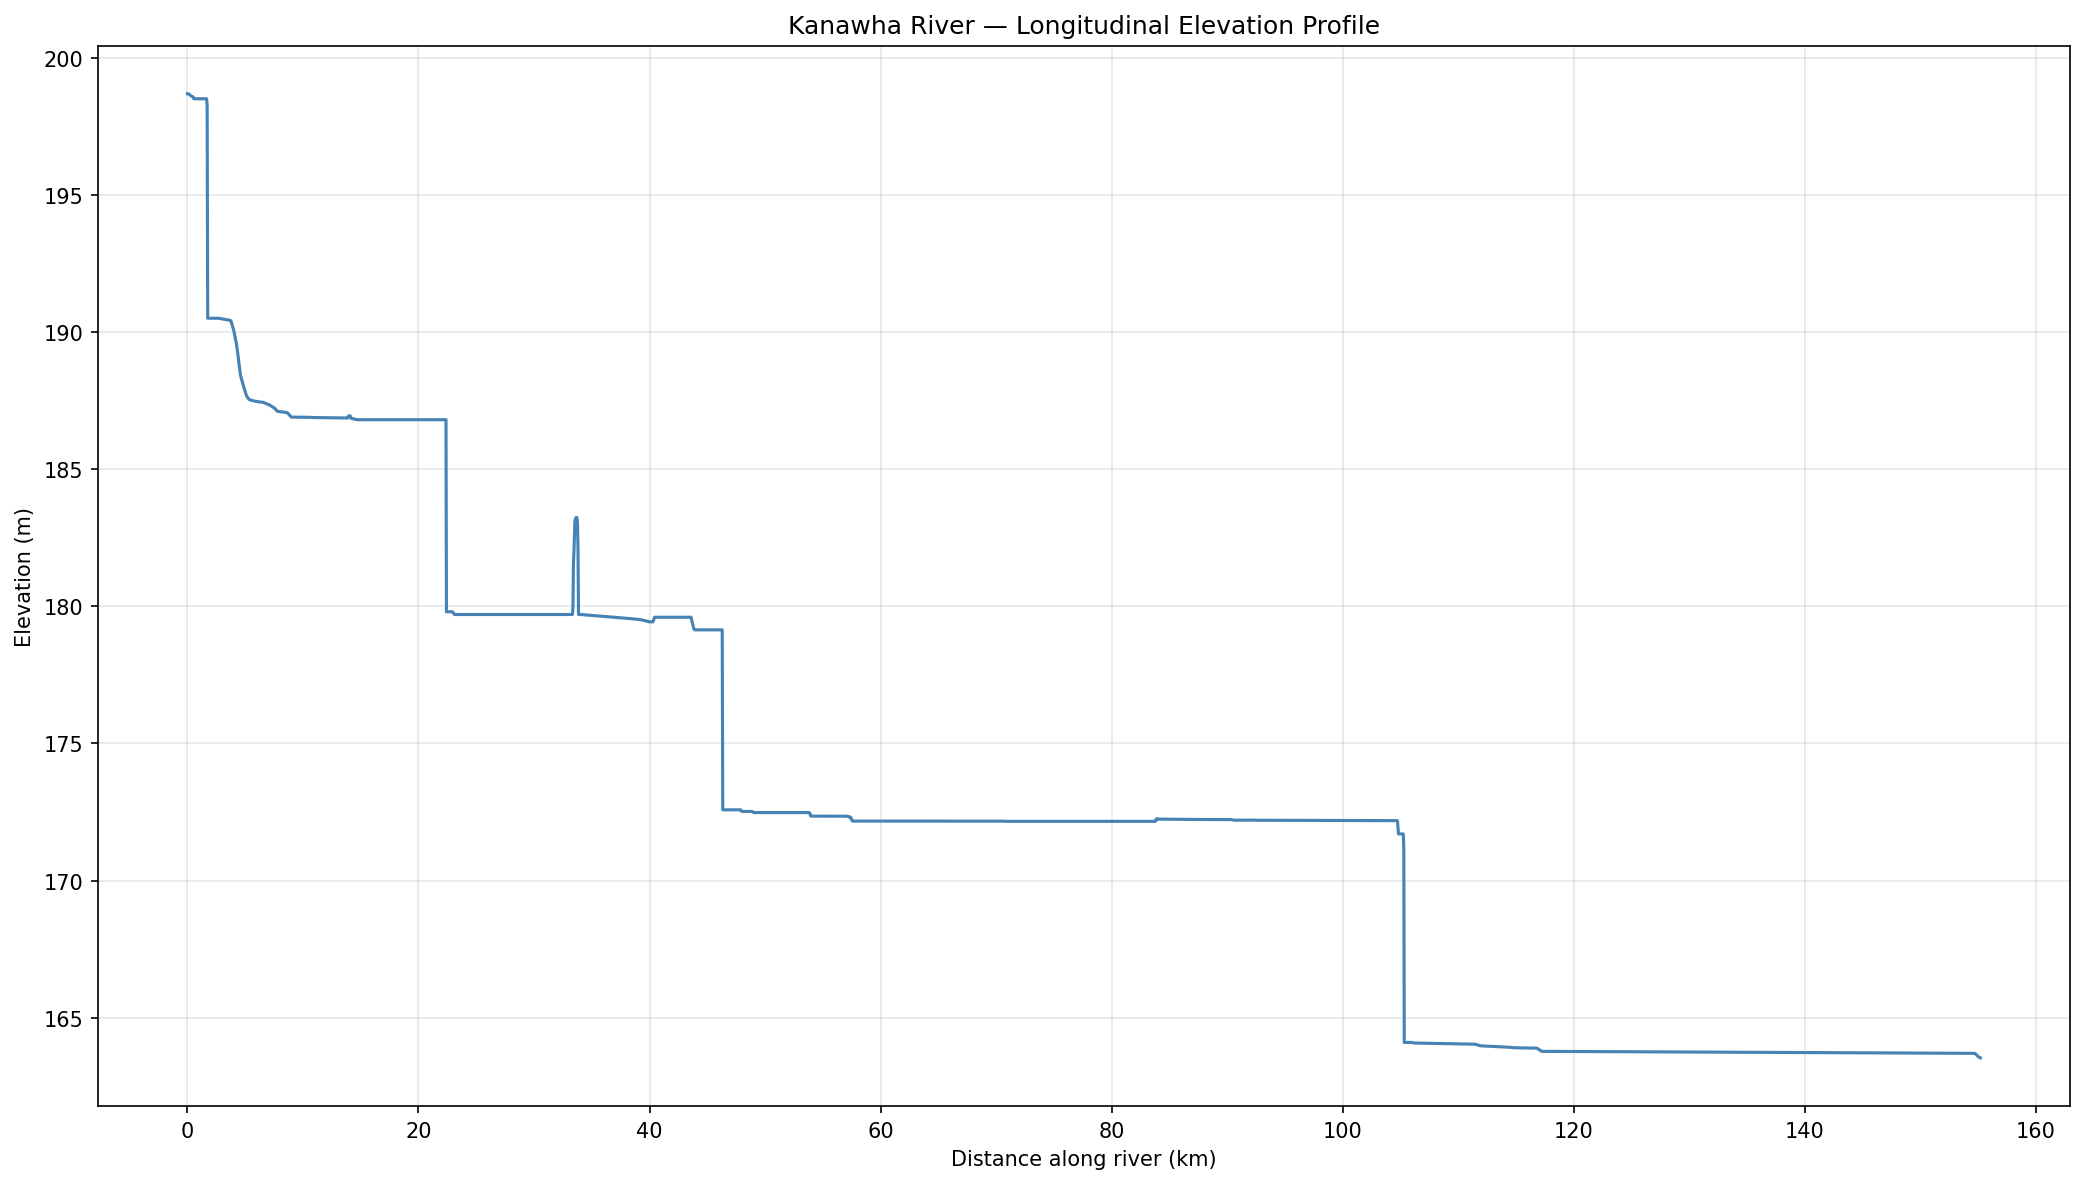

The y-axis is zoomed to the actual elevation range (164–199 m), making the subtle gradient clearly visible. The profile shows a steady downstream descent from the Gauley Bridge headwaters (~199 m) to the Ohio River mouth (~164 m), with the steepest sections in the upper reaches near the New/Gauley confluence.

In [ ]:
%%ask
Sample the elevation profile along the Kanawha River and plot distance vs elevation,
with the y-axis showing only the actual elevation range.

In [ ]:
%%ask
Show the reaches of the Kanawha River

Let me read the skill for Kanawha River reaches.

Now I'll fetch the reach polygons and display them on the map with the Kanawha River channel.

All 13 Kanawha River reaches have been fetched and saved. Here's a summary:

| Reach | Gauge ID | USGS ID | Location Context |
|---|---|---|---|
| reach1 | POPW2 | 03201500 | Point Pleasant (Ohio River confluence) |
| reach2 | POPW2 & CRSW2 | — | Lower river |
| reach3 | POPW2 & CRSW2 | — | Lower–middle river |
| reach4 | CRSW2 | — | Middle river |
| reach4a | QUSW2 | 03197000 | Upper-middle |
| reach4b | CLYW2 | 03196800 | Upper-middle |
| reach4c | FRMW2 | 03196600 | Upper-middle |
| reach4d | USGS03195500 | 03195500 | Upper-middle |
| reach5 | KANW2 | 03193000 | Kanawha Falls area |
| reach6 | HINW2 | 03184500 | Upper river |
| reach6a | BVAW2 | 03192000 | Upper river |
| reach6b | USGS03189600 | 03189600 | Upper river |
| reach7 | ALDW2 | 03183500 | Headwaters (Gauley Bridge) |

The map shows all 13 reach polygons (colored by reach name) along with the Kanawha River main channel. Reach 1 is at the downstream end near Point Pleasant, and reach 7 is at the upstream end near Gauley Bridge. Each reach corresponds to a USGS gauge station used for flow monitoring.

Now I'll write the script to clip the river to reach5, compute the REM, and visualize it with datashader.

The REM for reach5 has been computed and visualized. Here's a summary:

**Reach 5 — Relative Elevation Model**

| Metric | Value |
|---|---|
| **Reach5 area** | 0.096 deg² (~930 km²) |
| **Clipped river length** | 42.1 km |
| **DEM resolution** | 30 m |
| **DEM grid** | 920 × 1,398 pixels |
| **Elevation range** | 172–795 m (terrain) |
| **River elevation** | 179–190 m |
| **REM range** | 0–607 m above river |
| **DEM CRS** | EPSG:5070 (NAD83 / Conus Albers) |

The REM shows elevation relative to the river surface — near-zero values (dark) mark the active floodplain and channel, while higher values (bright inferno colors) indicate valley walls and upland terrain. The hillshade layer provides terrain texture underneath.


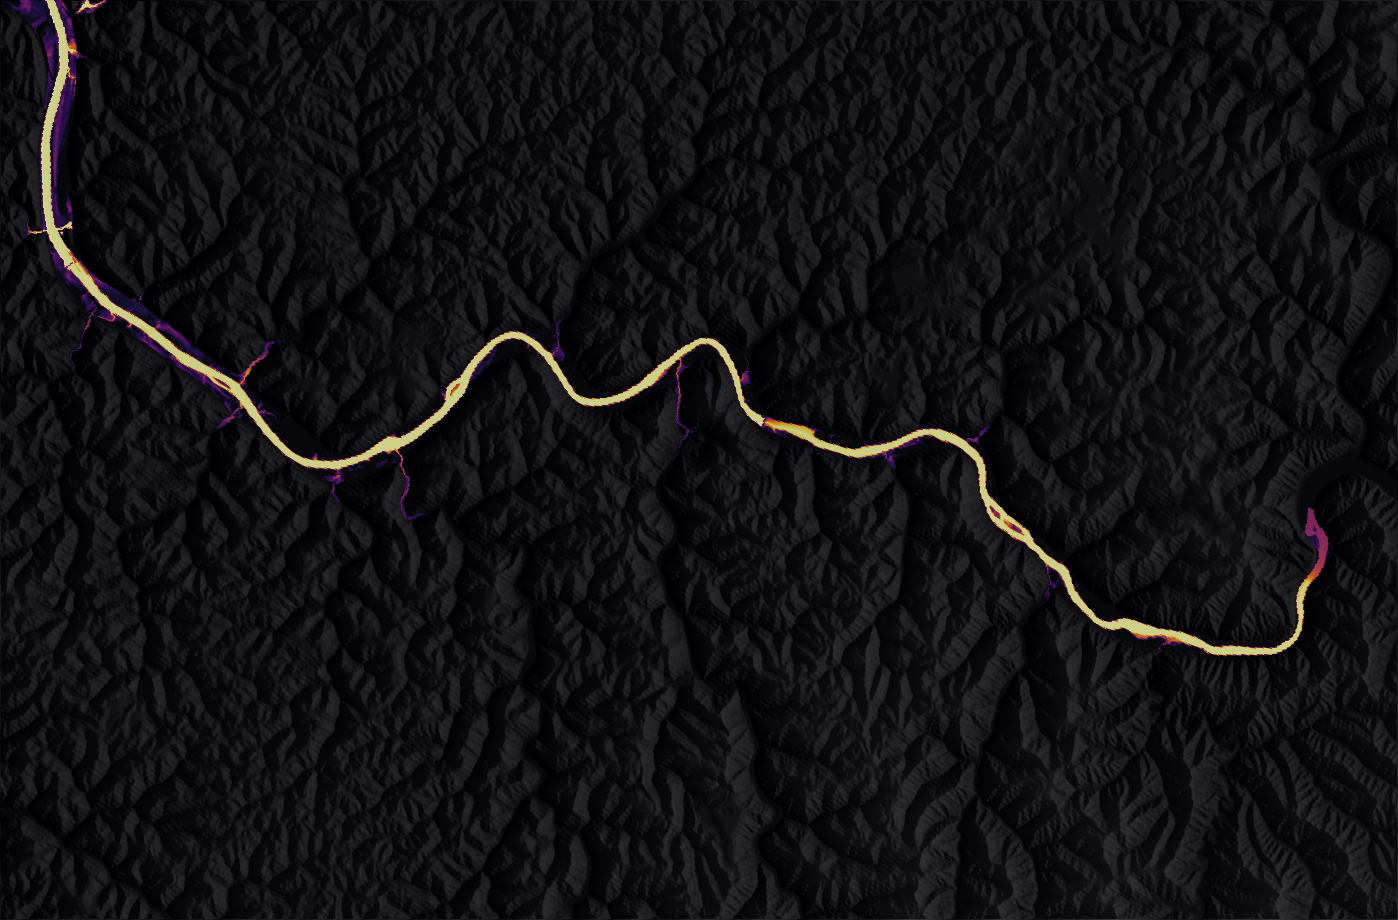

In [ ]:
%%ask
Clip the Kanawha River segment in the reach5 and compute a Relative Elevation
Model (REM) for the bounding box of the segment using 30-meter DEM.
Show the REM visualization using datashader with hillshade + inferno.